# Valio Aimo Purchase Orders Trend Analysis

## Challenge Context
This notebook analyzes purchase order data to identify trends that can help predict out-of-stock situations and improve delivery reliability.

**Key Objectives:**
1. Identify supplier reliability patterns
2. Discover shortage patterns (ordered vs received quantities)
3. Analyze temporal trends (seasonality, lead times)
4. Identify high-risk products and suppliers
5. Analyze partial delivery patterns
6. Create risk indicators for predictive modeling


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10

# Set pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)


## 1. Data Loading and Initial Exploration


In [2]:
# Load the purchases data
file_path = 'valio_aimo_purchases_junction_2025.csv'
df = pd.read_csv(file_path)

print(f"Purchase Orders data shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head(10)


Purchase Orders data shape: (782783, 11)

Column names: ['order_number', 'po_row_number', 'customer_number', 'po_created_date', 'requested_delivery_date', 'product_code', 'plant', 'storage_location', 'ordered_qty', 'unit', 'received_qty']

First few rows:


,order_number,po_row_number,customer_number,po_created_date,requested_delivery_date,product_code,plant,storage_location,ordered_qty,unit,received_qty
0,2300000000,10,30386,2024-09-01,2024-09-03,407329,1001,2011.00,8.00,ST,8.00
1,2300000001,10,30386,2024-09-01,2024-09-03,408060,1001,2011.00,3.00,ST,3.00
2,2300000002,10,30386,2024-09-01,2024-09-03,407332,1001,2011.00,4.00,ST,4.00
3,2300000002,20,30386,2024-09-01,2024-09-03,407326,1001,2011.00,4.00,ST,4.00
4,2300000003,10,30386,2024-09-01,2024-09-04,407466,1001,2011.00,4.00,RAS,4.00
5,2300000003,20,30386,2024-09-01,2024-09-04,410602,1001,2011.00,5.00,ST,5.00
6,2300000004,10,30386,2024-09-01,2024-09-09,412578,1001,2011.00,2.00,ST,2.00
7,2300000005,10,30386,2024-09-01,2024-09-03,407337,30588,2013.00,10.00,ST,10.00
8,2300000005,20,30386,2024-09-01,2024-09-03,407567,30588,2013.00,10.00,ST,10.00
9,2300000006,10,30386,2024-09-01,2024-09-03,410635,30588,2013.00,1.00,ST,1.00


In [3]:
# Convert date columns and calculate metrics
df['po_created_date'] = pd.to_datetime(df['po_created_date'])
df['requested_delivery_date'] = pd.to_datetime(df['requested_delivery_date'])

# Calculate lead time (days between order creation and requested delivery)
df['lead_time_days'] = (df['requested_delivery_date'] - df['po_created_date']).dt.days

# Calculate shortage metrics
df['shortage_qty'] = df['ordered_qty'] - df['received_qty']
df['fulfillment_rate'] = df['received_qty'] / df['ordered_qty']
df['is_shortage'] = (df['shortage_qty'] > 0.01).astype(int)  # Allow small rounding differences
df['is_zero_received'] = (df['received_qty'] == 0).astype(int)
df['is_partial'] = ((df['shortage_qty'] > 0.01) & (df['received_qty'] > 0)).astype(int)

# Extract temporal features
df['po_year'] = df['po_created_date'].dt.year
df['po_month'] = df['po_created_date'].dt.month
df['po_week'] = df['po_created_date'].dt.isocalendar().week
df['po_day_of_week'] = df['po_created_date'].dt.dayofweek
df['po_day_name'] = df['po_created_date'].dt.day_name()

print("Data preprocessing complete.")
print(f"Date range: {df['po_created_date'].min()} to {df['po_created_date'].max()}")
print(f"Total records: {len(df):,}")
print(f"\nBasic statistics:")
print(df[['ordered_qty', 'received_qty', 'shortage_qty', 'fulfillment_rate', 'lead_time_days']].describe())


Data preprocessing complete.
Date range: 2024-09-01 00:00:00 to 2025-09-30 00:00:00
Total records: 782,783

Basic statistics:
       ordered_qty  received_qty  shortage_qty  fulfillment_rate  \
count    782783.00     782783.00     782783.00         782782.00   
mean         19.96         19.25          0.71              0.98   
std          98.32         96.89         19.91              0.19   
min           0.00          0.00      -1056.00              0.00   
25%           1.00          1.00          0.00              1.00   
50%           2.00          2.00          0.00              1.00   
75%          10.00          9.00          0.00              1.00   
max       21000.00      20998.66       2800.00             40.00   

       lead_time_days  
count       782783.00  
mean             2.59  
std              5.43  
min           -365.00  
25%              1.00  
50%              1.00  
75%              3.00  
max            392.00  


## 2. Overall Shortage Analysis


In [4]:
# Overall shortage statistics
total_orders = len(df)
total_shortages = df['is_shortage'].sum()
total_zero_received = df['is_zero_received'].sum()
total_partial = df['is_partial'].sum()

total_ordered = df['ordered_qty'].sum()
total_received = df['received_qty'].sum()
total_shortage_qty = df['shortage_qty'].sum()

print("=== OVERALL SHORTAGE STATISTICS ===")
print(f"Total purchase order rows: {total_orders:,}")
print(f"Rows with shortages: {total_shortages:,} ({total_shortages/total_orders*100:.2f}%)")
print(f"Rows with zero received: {total_zero_received:,} ({total_zero_received/total_orders*100:.2f}%)")
print(f"Rows with partial delivery: {total_partial:,} ({total_partial/total_orders*100:.2f}%)")
print(f"\nTotal ordered quantity: {total_ordered:,.2f}")
print(f"Total received quantity: {total_received:,.2f}")
print(f"Total shortage quantity: {total_shortage_qty:,.2f}")
print(f"Overall fulfillment rate: {total_received/total_ordered*100:.2f}%")


=== OVERALL SHORTAGE STATISTICS ===
Total purchase order rows: 782,783
Rows with shortages: 29,162 (3.73%)
Rows with zero received: 18,860 (2.41%)
Rows with partial delivery: 10,310 (1.32%)

Total ordered quantity: 15,623,879.44
Total received quantity: 15,065,392.32
Total shortage quantity: 558,487.12
Overall fulfillment rate: 96.43%


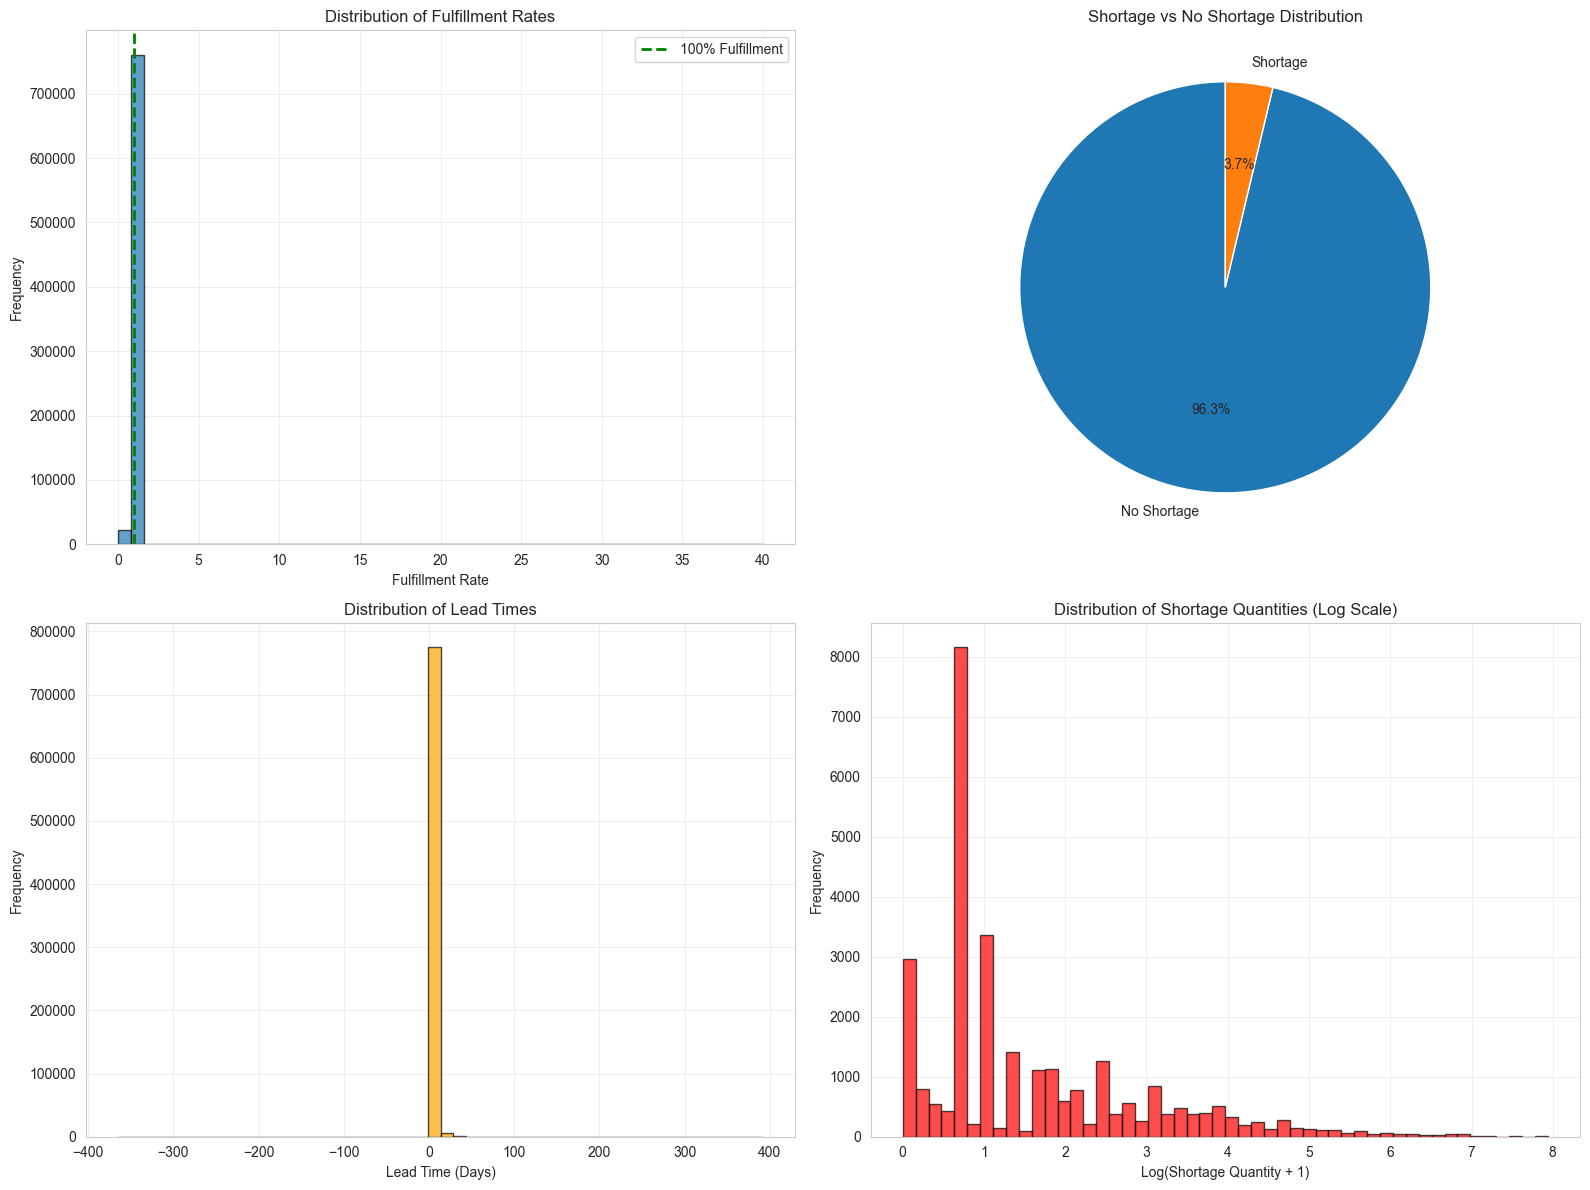

In [5]:
# Distribution of fulfillment rates
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Fulfillment rate distribution
axes[0, 0].hist(df['fulfillment_rate'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(x=1.0, color='green', linestyle='--', linewidth=2, label='100% Fulfillment')
axes[0, 0].set_xlabel('Fulfillment Rate')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Fulfillment Rates')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Shortage vs No Shortage
shortage_counts = df['is_shortage'].value_counts()
axes[0, 1].pie(shortage_counts.values, labels=['No Shortage', 'Shortage'], autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Shortage vs No Shortage Distribution')

# Lead time distribution
axes[1, 0].hist(df['lead_time_days'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].set_xlabel('Lead Time (Days)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Lead Times')
axes[1, 0].grid(True, alpha=0.3)

# Shortage quantity distribution (log scale for better visualization)
shortage_data = df[df['shortage_qty'] > 0]['shortage_qty']
if len(shortage_data) > 0:
    axes[1, 1].hist(np.log1p(shortage_data), bins=50, edgecolor='black', alpha=0.7, color='red')
    axes[1, 1].set_xlabel('Log(Shortage Quantity + 1)')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Distribution of Shortage Quantities (Log Scale)')
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 3. Temporal Trends (Seasonality Analysis)


In [6]:
# Monthly trends
monthly_stats = df.groupby('po_month').agg({
    'is_shortage': ['sum', 'mean'],
    'fulfillment_rate': 'mean',
    'ordered_qty': 'sum',
    'received_qty': 'sum',
    'shortage_qty': 'sum'
}).round(3)

monthly_stats.columns = ['Total_Shortages', 'Shortage_Rate', 'Avg_Fulfillment_Rate', 
                         'Total_Ordered', 'Total_Received', 'Total_Shortage_Qty']

print("=== MONTHLY TRENDS ===")
print(monthly_stats)


=== MONTHLY TRENDS ===
          Total_Shortages  Shortage_Rate  Avg_Fulfillment_Rate  Total_Ordered  \
po_month                                                                        
1                    1838           0.03                  0.98     1160076.10   
2                    1645           0.03                  0.98     1098496.47   
3                    1939           0.03                  0.98     1171451.63   
4                    2483           0.04                  0.97     1202484.02   
5                    2246           0.04                  0.98     1272027.90   
6                    2116           0.04                  0.98     1232765.07   
7                    1796           0.03                  0.98     1227448.50   
8                    2164           0.04                  0.98     1317914.12   
9                    6210           0.05                  0.97     2473347.75   
10                   2593           0.04                  0.98     1257634.21   
11   

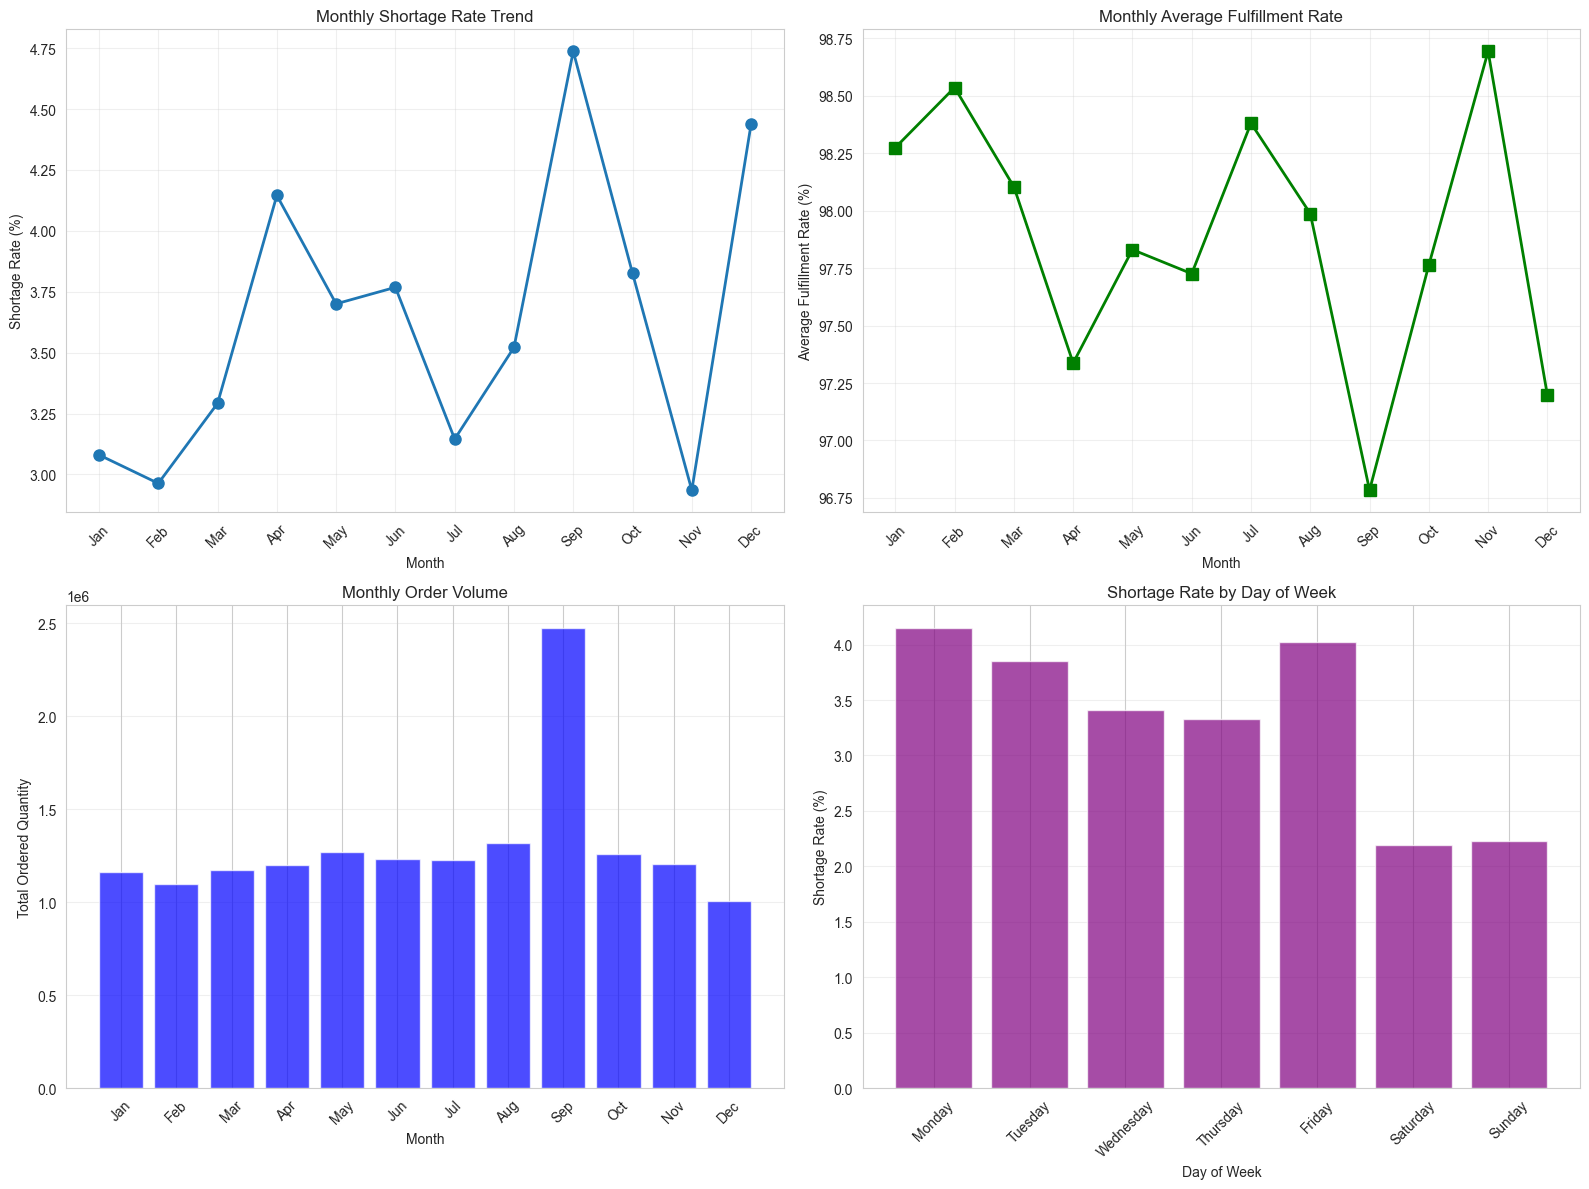

In [7]:
# Visualize monthly trends
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_nums = range(1, 13)

# Monthly shortage rate
monthly_shortage_rate = df.groupby('po_month')['is_shortage'].mean() * 100
axes[0, 0].plot(month_nums, [monthly_shortage_rate.get(m, 0) for m in month_nums], 
                marker='o', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Shortage Rate (%)')
axes[0, 0].set_title('Monthly Shortage Rate Trend')
axes[0, 0].set_xticks(month_nums)
axes[0, 0].set_xticklabels(months, rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# Monthly fulfillment rate
monthly_fulfillment = df.groupby('po_month')['fulfillment_rate'].mean() * 100
axes[0, 1].plot(month_nums, [monthly_fulfillment.get(m, 0) for m in month_nums], 
               marker='s', linewidth=2, markersize=8, color='green')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Average Fulfillment Rate (%)')
axes[0, 1].set_title('Monthly Average Fulfillment Rate')
axes[0, 1].set_xticks(month_nums)
axes[0, 1].set_xticklabels(months, rotation=45)
axes[0, 1].grid(True, alpha=0.3)

# Monthly order volume
monthly_volume = df.groupby('po_month')['ordered_qty'].sum()
axes[1, 0].bar(month_nums, [monthly_volume.get(m, 0) for m in month_nums], alpha=0.7, color='blue')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Total Ordered Quantity')
axes[1, 0].set_title('Monthly Order Volume')
axes[1, 0].set_xticks(month_nums)
axes[1, 0].set_xticklabels(months, rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Day of week trends
dow_shortage = df.groupby('po_day_name')['is_shortage'].mean() * 100
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
axes[1, 1].bar(range(len(day_order)), [dow_shortage.get(d, 0) for d in day_order], alpha=0.7, color='purple')
axes[1, 1].set_xlabel('Day of Week')
axes[1, 1].set_ylabel('Shortage Rate (%)')
axes[1, 1].set_title('Shortage Rate by Day of Week')
axes[1, 1].set_xticks(range(len(day_order)))
axes[1, 1].set_xticklabels(day_order, rotation=45)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## 4. Supplier Reliability Analysis (by Customer Number)


In [8]:
# Supplier reliability metrics
supplier_stats = df.groupby('customer_number').agg({
    'order_number': 'count',
    'is_shortage': ['sum', 'mean'],
    'is_zero_received': ['sum', 'mean'],
    'fulfillment_rate': 'mean',
    'ordered_qty': 'sum',
    'received_qty': 'sum',
    'shortage_qty': 'sum',
    'lead_time_days': 'mean'
}).round(3)

supplier_stats.columns = ['Total_Orders', 'Total_Shortages', 'Shortage_Rate', 
                         'Total_Zero_Received', 'Zero_Received_Rate',
                         'Avg_Fulfillment_Rate', 'Total_Ordered', 'Total_Received', 
                         'Total_Shortage_Qty', 'Avg_Lead_Time']

supplier_stats = supplier_stats.sort_values('Total_Orders', ascending=False)

print("=== TOP 20 SUPPLIERS BY ORDER VOLUME ===")
print(supplier_stats.head(20))


=== TOP 20 SUPPLIERS BY ORDER VOLUME ===
                 Total_Orders  Total_Shortages  Shortage_Rate  \
customer_number                                                 
30386                  131702             1703           0.01   
30554                   72957             1198           0.02   
30060                   35953             2030           0.06   
30520                   34573             1072           0.03   
30256                   28629              303           0.01   
30064                   23557             1698           0.07   
30198                   21069             1513           0.07   
400163                  18178              565           0.03   
30373                   16795              103           0.01   
30102                   16117              303           0.02   
400435                  13587             1019           0.07   
30359                   11058              438           0.04   
30048                   10145              104   

In [9]:
# Identify high-risk suppliers (high volume + high shortage rate)
high_volume_suppliers = supplier_stats[supplier_stats['Total_Orders'] >= 100]
high_risk_suppliers = high_volume_suppliers[high_volume_suppliers['Shortage_Rate'] > 0.1].sort_values(
    'Shortage_Rate', ascending=False
)

print("=== HIGH-RISK SUPPLIERS (100+ orders, >10% shortage rate) ===")
print(f"Number of high-risk suppliers: {len(high_risk_suppliers)}")
print(high_risk_suppliers.head(20))


=== HIGH-RISK SUPPLIERS (100+ orders, >10% shortage rate) ===
Number of high-risk suppliers: 63
                 Total_Orders  Total_Shortages  Shortage_Rate  \
customer_number                                                 
30584                     154               78           0.51   
30170                     144               61           0.42   
30530                     344              130           0.38   
30153                     317              114           0.36   
30490                     255               89           0.35   
30285                     184               56           0.30   
30465                     130               37           0.28   
30063                    1450              373           0.26   
30464                     128               31           0.24   
30283                     626              148           0.24   
30023                     125               29           0.23   
30317                    1208              273           0.

## 5. Product-Level Risk Analysis


In [10]:
# Product-level statistics
product_stats = df.groupby('product_code').agg({
    'order_number': 'count',
    'is_shortage': ['sum', 'mean'],
    'is_zero_received': ['sum', 'mean'],
    'fulfillment_rate': 'mean',
    'ordered_qty': 'sum',
    'received_qty': 'sum',
    'shortage_qty': 'sum'
}).round(3)

product_stats.columns = ['Total_Orders', 'Total_Shortages', 'Shortage_Rate', 
                         'Total_Zero_Received', 'Zero_Received_Rate',
                         'Avg_Fulfillment_Rate', 'Total_Ordered', 'Total_Received', 
                         'Total_Shortage_Qty']

product_stats = product_stats.sort_values('Total_Orders', ascending=False)

print("=== TOP 20 PRODUCTS BY ORDER VOLUME ===")
print(product_stats.head(20))


=== TOP 20 PRODUCTS BY ORDER VOLUME ===
              Total_Orders  Total_Shortages  Shortage_Rate  \
product_code                                                 
407338               20554              536           0.03   
407474               12483               79           0.01   
407451                8067               50           0.01   
409887                6319              370           0.06   
407327                5927              188           0.03   
410602                5481               34           0.01   
409881                4884              489           0.10   
407326                4830              335           0.07   
409886                4564              249           0.06   
407464                4187               22           0.01   
407337                3855               34           0.01   
407470                3747               10           0.00   
410635                3426               11           0.00   
407332                3271    

In [11]:
# High-risk products (frequently ordered + high shortage rate)
high_volume_products = product_stats[product_stats['Total_Orders'] >= 50]
high_risk_products = high_volume_products[high_volume_products['Shortage_Rate'] > 0.15].sort_values(
    'Shortage_Rate', ascending=False
)

print("=== HIGH-RISK PRODUCTS (50+ orders, >15% shortage rate) ===")
print(f"Number of high-risk products: {len(high_risk_products)}")
print(high_risk_products.head(30))


=== HIGH-RISK PRODUCTS (50+ orders, >15% shortage rate) ===
Number of high-risk products: 166
              Total_Orders  Total_Shortages  Shortage_Rate  \
product_code                                                 
408742                  92               83           0.90   
402542                 278              229           0.82   
411238                 123               97           0.79   
413989                  51               40           0.78   
402368                 251              182           0.72   
407978                  59               39           0.66   
406337                 150               99           0.66   
403048                 124               73           0.59   
404925                  51               30           0.59   
413227                 192              110           0.57   
400199                  57               32           0.56   
415804                 157               84           0.54   
412536                  73            

## 6. Partial Delivery Analysis


In [12]:
# Analyze partial deliveries (same order_number, po_row_number appears multiple times)
partial_delivery_analysis = df.groupby(['order_number', 'po_row_number']).agg({
    'received_qty': ['count', 'sum'],
    'ordered_qty': 'first',
    'product_code': 'first',
    'customer_number': 'first'
}).reset_index()

partial_delivery_analysis.columns = ['order_number', 'po_row_number', 'delivery_count', 
                                     'total_received', 'ordered_qty', 'product_code', 'customer_number']

# Identify orders with multiple deliveries
multi_delivery_orders = partial_delivery_analysis[partial_delivery_analysis['delivery_count'] > 1]

print(f"=== PARTIAL DELIVERY ANALYSIS ===")
print(f"Total unique order rows: {len(partial_delivery_analysis):,}")
print(f"Order rows with multiple deliveries: {len(multi_delivery_orders):,} ({len(multi_delivery_orders)/len(partial_delivery_analysis)*100:.2f}%)")
print(f"\nDistribution of delivery counts:")
print(partial_delivery_analysis['delivery_count'].value_counts().sort_index().head(10))

print(f"\n=== SAMPLE MULTI-DELIVERY ORDERS ===")
print(multi_delivery_orders.head(20))


=== PARTIAL DELIVERY ANALYSIS ===
Total unique order rows: 782,634
Order rows with multiple deliveries: 149 (0.02%)

Distribution of delivery counts:
delivery_count
1    782485
2       149
Name: count, dtype: int64

=== SAMPLE MULTI-DELIVERY ORDERS ===
        order_number  po_row_number  delivery_count  total_received  \
5758      2300002370             20               2            2.00   
11530     2300004710             10               2            6.00   
14999     2300005951             10               2            2.26   
20299     2300008212             10               2            5.00   
26559     2300010706             20               2            2.00   
41616     2300016712             30               2            9.00   
44379     2300017660             10               2            3.38   
48754     2300019550            430               2           14.00   
55550     2300022402             70               2            8.00   
58822     2300023620             10  

## 7. Lead Time Analysis


In [13]:
# Lead time vs shortage relationship
lead_time_bins = pd.cut(df['lead_time_days'], bins=[0, 1, 2, 3, 5, 7, 14, 30, 100])
lead_time_analysis = df.groupby(lead_time_bins).agg({
    'is_shortage': 'mean',
    'fulfillment_rate': 'mean',
    'order_number': 'count'
}).round(3)

lead_time_analysis.columns = ['Shortage_Rate', 'Avg_Fulfillment_Rate', 'Order_Count']

print("=== LEAD TIME VS SHORTAGE ANALYSIS ===")
print(lead_time_analysis)


=== LEAD TIME VS SHORTAGE ANALYSIS ===
                Shortage_Rate  Avg_Fulfillment_Rate  Order_Count
lead_time_days                                                  
(0, 1]                   0.03                  0.98       393287
(1, 2]                   0.04                  0.97        94657
(2, 3]                   0.04                  0.98       105451
(3, 5]                   0.04                  0.98        85519
(5, 7]                   0.04                  0.98        46472
(7, 14]                  0.05                  0.98        28845
(14, 30]                 0.07                  0.97         3890
(30, 100]                0.16                  0.86         1274


## 8. Key Insights Summary


In [14]:
print("=" * 80)
print("KEY INSIGHTS FOR PREDICTIVE AI MODEL")
print("=" * 80)

print("\n1. OVERALL SHORTAGE PATTERNS:")
print(f"   - Overall shortage rate: {df['is_shortage'].mean()*100:.2f}%")
print(f"   - Zero-received rate: {df['is_zero_received'].mean()*100:.2f}%")
print(f"   - Overall fulfillment rate: {df['fulfillment_rate'].mean()*100:.2f}%")

print("\n2. SUPPLIER RELIABILITY:")
high_volume_suppliers = supplier_stats[supplier_stats['Total_Orders'] >= 100]
high_risk_suppliers = high_volume_suppliers[high_volume_suppliers['Shortage_Rate'] > 0.1].sort_values(
    'Shortage_Rate', ascending=False
)
print(f"   - {len(high_risk_suppliers)} high-risk suppliers identified (100+ orders, >10% shortage)")
if len(high_risk_suppliers) > 0:
    worst_supplier = high_risk_suppliers.iloc[0]
    print(f"   - Worst supplier: {worst_supplier.name} ({worst_supplier['Shortage_Rate']*100:.2f}% shortage rate)")

print("\n3. PRODUCT RISK:")
high_volume_products = product_stats[product_stats['Total_Orders'] >= 50]
high_risk_products = high_volume_products[high_volume_products['Shortage_Rate'] > 0.15].sort_values(
    'Shortage_Rate', ascending=False
)
print(f"   - {len(high_risk_products)} high-risk products identified (50+ orders, >15% shortage)")
if len(high_risk_products) > 0:
    worst_product = high_risk_products.iloc[0]
    print(f"   - Worst product: {worst_product.name} ({worst_product['Shortage_Rate']*100:.2f}% shortage rate)")

print("\n4. TEMPORAL PATTERNS:")
monthly_risk = df.groupby('po_month')['is_shortage'].mean()
print(f"   - Month with highest shortage rate: {monthly_risk.idxmax()} ({monthly_risk.max()*100:.2f}%)")
print(f"   - Month with lowest shortage rate: {monthly_risk.idxmin()} ({monthly_risk.min()*100:.2f}%)")

print("\n5. LEAD TIME IMPACT:")
avg_lead_time = df['lead_time_days'].mean()
print(f"   - Average lead time: {avg_lead_time:.2f} days")
print(f"   - Lead time range: {df['lead_time_days'].min():.0f} to {df['lead_time_days'].max():.0f} days")

print("\n6. PARTIAL DELIVERIES:")
print(f"   - {len(multi_delivery_orders)/len(partial_delivery_analysis)*100:.2f}% of orders have multiple deliveries")
print(f"   - Average deliveries per multi-delivery order: {multi_delivery_orders['delivery_count'].mean():.2f}")

print("\n7. RECOMMENDATIONS FOR AI MODEL:")
print("   - Use supplier historical shortage rate as a key feature")
print("   - Include product-level shortage history")
print("   - Consider seasonal/monthly patterns")
print("   - Factor in lead time as a risk indicator")
print("   - Monitor high-risk supplier-product combinations")
print("   - Track partial delivery patterns for early warning")

print("\n" + "=" * 80)


KEY INSIGHTS FOR PREDICTIVE AI MODEL

1. OVERALL SHORTAGE PATTERNS:
   - Overall shortage rate: 3.73%
   - Zero-received rate: 2.41%
   - Overall fulfillment rate: 97.79%

2. SUPPLIER RELIABILITY:
   - 63 high-risk suppliers identified (100+ orders, >10% shortage)
   - Worst supplier: 30584 (50.60% shortage rate)

3. PRODUCT RISK:
   - 166 high-risk products identified (50+ orders, >15% shortage)
   - Worst product: 408742 (90.20% shortage rate)

4. TEMPORAL PATTERNS:
   - Month with highest shortage rate: 9 (4.74%)
   - Month with lowest shortage rate: 11 (2.94%)

5. LEAD TIME IMPACT:
   - Average lead time: 2.59 days
   - Lead time range: -365 to 392 days

6. PARTIAL DELIVERIES:
   - 0.02% of orders have multiple deliveries
   - Average deliveries per multi-delivery order: 2.00

7. RECOMMENDATIONS FOR AI MODEL:
   - Use supplier historical shortage rate as a key feature
   - Include product-level shortage history
   - Consider seasonal/monthly patterns
   - Factor in lead time as a r